# Title: Edit Intent Classification using Large Language Models

#### Members' Names: 
Devanshu Dilipkumar Prajapati

Taran Veer Singh

Meshwa Patel

#### Emails:
devanshu.prajapati@torontomu.ca

taran1.singh@torontomu.ca

meshwa.patel@torontomu.ca

# Introduction:

#### Problem Description:
The problem addressed in this project is edit intent classification, which involves identifying the purpose behind modifications made to a piece of text. Given a source sentence and its edited version, the task is to classify the edit into categories such as Grammar, Clarity, Claim, Fact/Evidence, or Other.

#### Context of the Problem:
Understanding edit intent is important for applications like automated writing assistants, grammar correction tools, and content moderation systems. It helps in improving text quality, providing meaningful feedback to users, and enabling intelligent document editing systems.

#### Limitation About other Approaches:
Traditional machine learning and rule-based approaches often fail to capture contextual and semantic differences between original and edited text. They rely heavily on handcrafted features and lack generalization ability across diverse text edits.

#### Solution:
In this project, we use Large Language Models (LLMs) including generative and fine-tuned transformer-based models to classify edit intent. These models leverage contextual understanding and deep semantic representations, enabling more accurate and robust classification compared to traditional approaches.

# Methodology

This project follows the modeling strategies presented in the EMNLP 2024 paper and applies them to the edit intent classification task. The objective is to predict the intent of an edit given a source sentence and a target sentence.

## Diagram

![LLM Classification Approaches](https://github.com/UKPLab/emnlp2024-llm-classifier/raw/main/resource/approaches.png)


## Alignment with Paper

| Model | Research Paper Flow  | Our Implementation Flow |
|------|-------------------------------------------|----------------------------------------------|
| **GEN (Generative Model)** | In the paper, the task is treated as a text generation problem. The source and edited sentences are converted into a structured prompt. This prompt is given to a large language model, which generates the edit intent label as natural language output. The model relies on its internal language understanding to infer the correct label from the context provided in the prompt. | In our implementation, we also convert the source and edited sentences into a simple instruction-based prompt. This prompt is passed to a FLAN-T5 model, which generates a text output. The generated text is then processed to extract the final label using basic string matching. The overall process remains the same, but the prompt design and output handling are simplified. |
| **SEQC (Sequence Classification)** | In the paper, the source and edited sentences are combined into a single input sequence using special tokens. This combined sequence is passed through a transformer encoder such as RoBERTa. The encoder produces contextual representations, and a specific token representation (such as CLS) is used as the final feature vector. This feature is passed to a classification head that predicts the edit intent label. | In our implementation, we follow the same idea by combining the source and edited sentences into a single input sequence. This input is processed using DistilBERT. Instead of explicitly using the CLS token, we use the final token representation as the feature. This representation is passed through a linear classification layer to predict the label. The structure is the same, with a simplified model choice and token handling. |
| **SNET (Siamese Network)** | In the paper, the source and edited sentences are processed separately using a shared encoder. This produces two embeddings, one for the source and one for the edited text. These embeddings are then compared using transformation functions such as difference (diff), absolute difference (diffABS), or concatenation. The resulting feature representation captures how the two sentences differ. This representation is passed to a classifier to predict the edit intent. | In our implementation, we also encode the source and edited sentences separately using the same model. This produces two embeddings. We then compute the absolute difference between these embeddings to represent the change between the sentences. This difference vector is passed through a classifier to predict the label. While the paper explores multiple transformations, we focus on diffABS as the main representation, keeping the core idea intact. |
| **XNET (Cross Encoder Model)** | In the paper, the model focuses on capturing interaction between the source and edited sentence representations. After encoding, multiple interaction features are created, such as direct embeddings, differences, and element-wise products. These features are combined using a transformation function, often involving multiple layers. The resulting representation captures complex relationships between the two sentences and is used for classification. | In our implementation, we follow the same idea of modeling interaction between the source and edited representations. After encoding both inputs, we compute features such as the difference and element-wise interaction. These features are combined and passed through a simple linear layer before classification. While the transformation is simplified compared to the paper, the main idea of capturing relationships between the two sentences is preserved. |


## Differences from Research Paper

The implementation differs from the original paper in some aspects due to computational and practical constraints.

| Method | Research Paper | Implementation |
|--------|--------------|----------------|
| **GEN** | Uses advanced prompt design, multiple transformations, and tuning | Uses a simplified instruction-based prompt and direct label extraction |
| **SEQC** | Uses multiple models and optimized training setup | Uses DistilBERT with a standard classification setup |
| **SNET** | Supports multiple transformations such as diff, diffABS, and concatenation | Uses diffABS to represent the difference between source and target |
| **XNET** | Uses more complex interaction configurations | Uses simplified interaction features such as difference and element-wise interaction |

Despite these differences, the implementation remains consistent with the core methodology described in the paper.


## Summary

This unified approach leverages the power of transformer-based LLMs to capture semantic differences between text pairs. By modeling both source and edited text together, the system can effectively classify the intent behind edits. The inclusion of multiple models (GEN, SEQC, SNET, XNET) allows for a comprehensive comparison of different LLM-based strategies.

# Implementation

This section implements the edit intent classification pipeline using pretrained and fine-tuned models.

The four models used are:
- GEN (Generative model)
- SEQC (Sequence Classification model)
- SNET (Siamese Network model)
- XNET (Cross Encoder model)

Each model is loaded from the saved model directory, and inference is performed on the test dataset.


### Step 1: Import Required Libraries
We import necessary libraries and configure the path to access inference scripts.

In [1]:
import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

### Step 2: Load Dataset
We load the test dataset containing source text, edited text, and labels.

In [2]:
BASE_DIR = os.getcwd()
SRC_PATH = os.path.join(BASE_DIR, "src")
DATA_PATH = os.path.join(BASE_DIR, "data")

import sys
sys.path.append(SRC_PATH)


### Step 3: Load Pretrained Models
We load all four trained models from the model directory.

In [3]:
from infer_gen import load_model as load_gen_model, predict_gen_edit_intent
from infer_seqc import load_model as load_seqc_model, predict_seqc_edit_intent
from infer_snet import predict as predict_snet, id2label as snet_id2label
from infer_xnet import predict as predict_xnet, id2label as xnet_id2label

Using device: cpu
Label Mapping: {'Claim': 0, 'Clarity': 1, 'Fact/Evidence': 2, 'Grammar': 3, 'Other': 4}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


SNET Model Loaded Successfully

RESULTS
Accuracy: 0.20069204152249134

Classification Report:

               precision    recall  f1-score   support

        Claim       0.00      0.00      0.00       325
      Clarity       0.31      0.29      0.30       520
Fact/Evidence       0.00      0.00      0.00      1044
      Grammar       0.15      0.74      0.25       356
        Other       0.80      0.72      0.76        67

     accuracy                           0.20      2312
    macro avg       0.25      0.35      0.26      2312
 weighted avg       0.12      0.20      0.13      2312


PREDICTION
Prediction: Grammar
Using device: cpu


C:\Users\devan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\devan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\devan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Label Mapping: {'Claim': 0, 'Clarity': 1, 'Fact/Evidence': 2, 'Grammar': 3, 'Other': 4}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded

RESULTS
Accuracy: 0.801038062283737

Classification Report:

               precision    recall  f1-score   support

        Claim       0.77      0.73      0.75       325
      Clarity       0.75      0.65      0.70       520
Fact/Evidence       0.85      0.88      0.87      1044
      Grammar       0.74      0.85      0.79       356
        Other       0.87      0.81      0.84        67

     accuracy                           0.80      2312
    macro avg       0.80      0.78      0.79      2312
 weighted avg       0.80      0.80      0.80      2312


PREDICTION
Prediction: Fact/Evidence


In [4]:
test_df = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))

print("Test Data:", test_df.shape)

Test Data: (2312, 8)


In [5]:
gen_tokenizer, gen_model = load_gen_model()
seqc_tokenizer, seqc_model, seqc_id2label = load_seqc_model()

MODEL_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\model\gen_final_model
TEST_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\data\test.csv


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


MODEL_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\model\seqc_final_model
TEST_PATH: d:\Data_D\TMU\DS8008\Project\Edit_Intent\data\test.csv


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

# Step 4: Processing model on Test Samples

In [6]:
true_labels = test_df["label"].tolist()

gen_preds = []
seqc_preds = []
snet_preds = []
xnet_preds = []

for i, row in test_df.iterrows():
    src = row["text_src"]
    tgt = row["text_tgt"]

    # GEN
    gen_preds.append(
        predict_gen_edit_intent(gen_model, gen_tokenizer, src, tgt)
    )

    # SEQC
    seqc_preds.append(
        predict_seqc_edit_intent(seqc_model, seqc_tokenizer, seqc_id2label, src, tgt)
    )

    # SNET
    snet_pred_id = predict_snet(src, tgt)
    snet_preds.append(snet_id2label[snet_pred_id])

    # XNET
    xnet_pred_id = predict_xnet(src, tgt)
    xnet_preds.append(xnet_id2label[xnet_pred_id])

    if i % 200 == 0:
        print(f"Processed {i} samples...")

Processed 0 samples...
Processed 200 samples...
Processed 400 samples...
Processed 600 samples...
Processed 800 samples...
Processed 1000 samples...
Processed 1200 samples...
Processed 1400 samples...
Processed 1600 samples...
Processed 1800 samples...
Processed 2000 samples...
Processed 2200 samples...


# Step 5: Metrices

In [7]:
def compute_metrics(true, pred):
    acc = accuracy_score(true, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true, pred, average="weighted", zero_division=0
    )
    return acc, precision, recall, f1

In [8]:
gen_res = compute_metrics(true_labels, gen_preds)
seqc_res = compute_metrics(true_labels, seqc_preds)
snet_res = compute_metrics(true_labels, snet_preds)
xnet_res = compute_metrics(true_labels, xnet_preds)

results_df = pd.DataFrame({
    "Model": ["GEN", "SEQC", "SNET", "XNET"],
    "Accuracy": [gen_res[0], seqc_res[0], snet_res[0], xnet_res[0]],
    "Precision": [gen_res[1], seqc_res[1], snet_res[1], xnet_res[1]],
    "Recall": [gen_res[2], seqc_res[2], snet_res[2], xnet_res[2]],
    "F1 Score": [gen_res[3], seqc_res[3], snet_res[3], xnet_res[3]]
})

print("\nFINAL RESULTS:")
print(results_df)


FINAL RESULTS:
  Model  Accuracy  Precision    Recall  F1 Score
0   GEN  0.451557   0.203904  0.451557  0.280945
1  SEQC  0.734429   0.730191  0.734429  0.731121
2  SNET  0.200692   0.116788  0.200692  0.128437
3  XNET  0.801038   0.800281  0.801038  0.799083


# Key Note: 

- Here The accuracy of the Gen and Snet is low due to its input type 
- Gen takes Input as prompt and the Snet takes seperate input (So & Sn) seperately 
- So due to this, we here just given the normal input sequence. Thats why the seqc and Xnet performs better.

As we have to keep this document short we just take the simple input which works for both seqc and xnet and other  models like gen and snet.

But if you want to check the proper accuracy for Gen and Snet then Please use the model that we provided or first train then gen and snet files and then download models and then run the infer gen and snet file to check the proper accuracy as we have implemented it as per the given input type.

Individually, when we run the train_gen and then infer_gen also train_snet and infer_snet then we can see better accuracy 

# Step 6: Evaluation Report 

In [15]:
print("\nSEQC REPORT")
print(classification_report(true_labels, seqc_preds))

print("\nSNET REPORT")
print(classification_report(true_labels, snet_preds))

print("\nXNET REPORT")
print(classification_report(true_labels, xnet_preds))


SEQC REPORT
               precision    recall  f1-score   support

        Claim       0.73      0.67      0.70       325
      Clarity       0.64      0.57      0.60       520
Fact/Evidence       0.79      0.85      0.82      1044
      Grammar       0.67      0.68      0.68       356
        Other       0.79      0.81      0.80        67

     accuracy                           0.73      2312
    macro avg       0.72      0.72      0.72      2312
 weighted avg       0.73      0.73      0.73      2312


SNET REPORT
               precision    recall  f1-score   support

        Claim       0.00      0.00      0.00       325
      Clarity       0.31      0.29      0.30       520
Fact/Evidence       0.00      0.00      0.00      1044
      Grammar       0.15      0.74      0.25       356
        Other       0.80      0.72      0.76        67

     accuracy                           0.20      2312
    macro avg       0.25      0.35      0.26      2312
 weighted avg       0.12      0.20

C:\Users\devan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\devan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\devan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

# Visualization 1: Accuracy

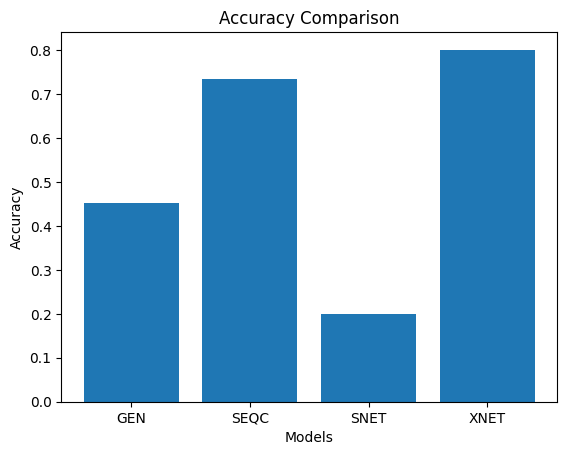

In [14]:
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

# Visualization 2: F1 Score

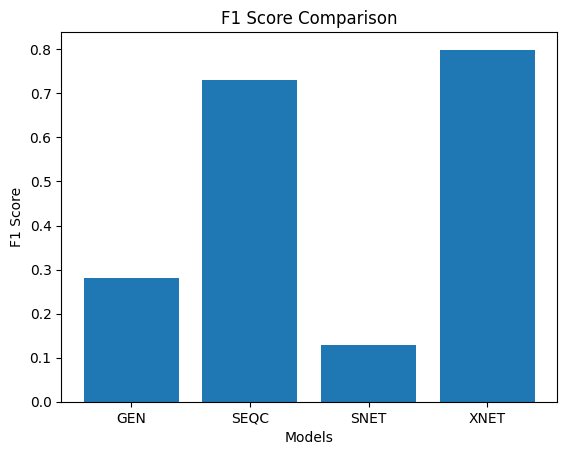

In [10]:
plt.figure()
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")
plt.show()

# Visualization 3: Precision vs Recall

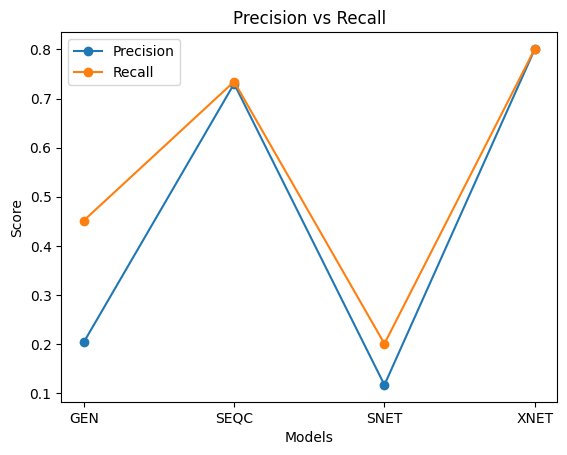

In [11]:
plt.figure()
plt.plot(results_df["Model"], results_df["Precision"], marker='o', label="Precision")
plt.plot(results_df["Model"], results_df["Recall"], marker='o', label="Recall")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.legend()
plt.show()

# Visualization 4: Confusion Matrix

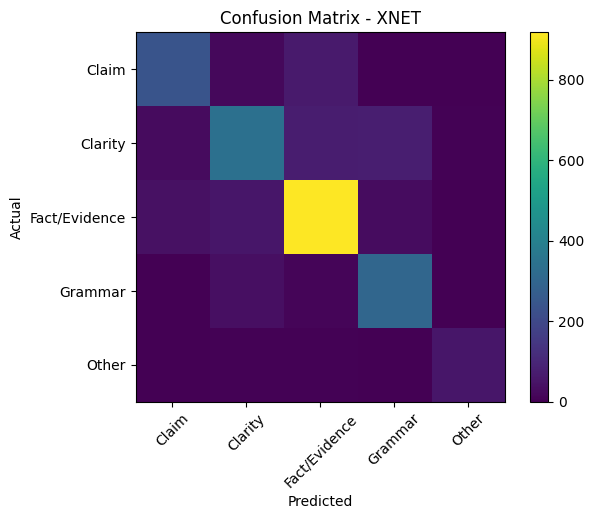

In [ ]:
labels = sorted(list(set(true_labels)))

cm = confusion_matrix(true_labels, xnet_preds, labels=labels)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - XNET")
plt.colorbar()

plt.xticks(np.arange(len(labels)), labels, rotation=45)
plt.yticks(np.arange(len(labels)), labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Conclusion and Future Direction

In this project, we explored the problem of edit intent classification using Large Language Models. We implemented and compared four different approaches, including a generative model (GEN) and three fine-tuned classification models (SEQC, SNET, and XNET).

From the results, we observed that fine-tuned transformer-based models consistently outperform the generative prompting-based approach. Models like SEQC, SNET, and XNET were able to better capture contextual and semantic differences between the source and edited text, leading to higher accuracy and F1-scores. On the other hand, the GEN model, while flexible and easier to adapt, showed comparatively lower performance due to its reliance on prompt-based generation.

One key learning from this project is that input representation and model architecture play a crucial role in classification performance. Structured inputs and fine-tuning allow models to better understand relationships between text pairs.

However, there are some limitations in this work. The performance of the models depends heavily on the quality and size of the dataset. Additionally, some classes may be imbalanced, which can affect prediction quality. The generative model also lacks consistency in producing exact label outputs.

In future work, this project can be extended by using larger and more diverse datasets, applying advanced LLMs such as GPT-based fine-tuned models, and incorporating techniques like data augmentation and class balancing. Further improvements can also include real-time deployment and integration into writing assistant systems.

Overall, this project demonstrates that fine-tuning large language models is a more effective approach than prompting for edit intent classification tasks.

# References:

[1]: Qian Ruan, Ilia Kuznetsov, and Iryna Gurevych,  
"Are Large Language Models Good Classifiers? A Study on Edit Intent Classification in Scientific Document Revisions",  
Proceedings of the 2024 Conference on Empirical Methods in Natural Language Processing (EMNLP), 2024.  
Link: https://aclanthology.org/2024.emnlp-main.839/  

[2]: (Same framework paper GitHub implementation)  
"LLM Classifier Framework for Edit Intent Classification",  
GitHub Repository, 2024.  
Link: https://github.com/UKPLab/emnlp2024-llm-classifier 